In [1]:
import pandas as pd

In [25]:
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("retail_sales.csv")

In [5]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,11/24/2023,CUST001,Male,34,Beauty,3,50,150
1,2,2/27/2023,CUST002,Female,26,Clothing,2,500,1000
2,3,1/13/2023,CUST003,Male,50,Electronics,1,30,30
3,4,5/21/2023,CUST004,Male,37,Clothing,1,500,500
4,5,5/6/2023,CUST005,Male,30,Beauty,2,50,100


In [7]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [8]:
df.shape

(1000, 9)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [10]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [11]:
df.dtypes

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

In [12]:
df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].mean()

Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

In [13]:
df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].mode()

,Age,Quantity,Price per Unit,Total Amount
0,43,4.0,50.0,50.0
1,64,NaN,NaN,NaN


In [14]:
df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].std()

Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

In [15]:
df['Date'] = pd.to_datetime(df['Date'])

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


In [20]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

In [21]:
monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

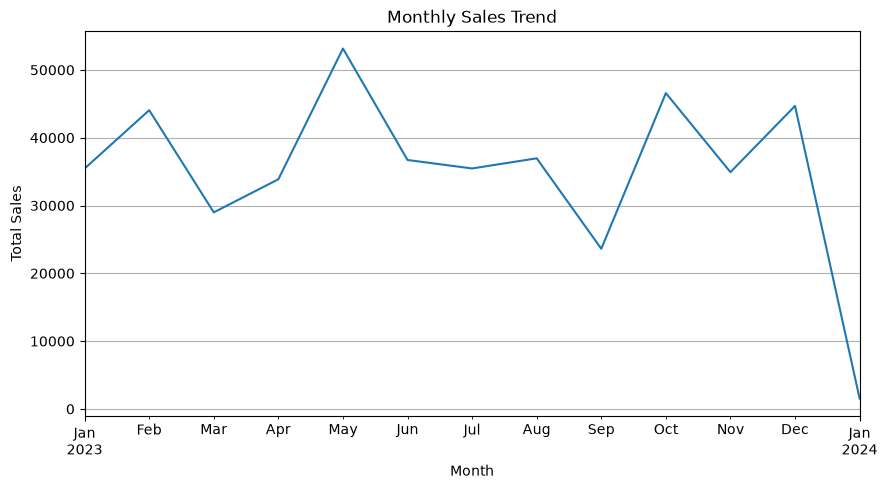

In [26]:
monthly_sales.plot(kind='line', figsize=(10, 5))

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

### Monthly Sales Trend

Monthly sales fluctuated throughout the period, with noticeable increases and decreases across the months. The trend shows that sales performance was not consistent throughout the year.

In [27]:
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()

In [28]:
'M'

'M'

In [29]:
'Q'

'Q'

In [30]:
quarterly_sales

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

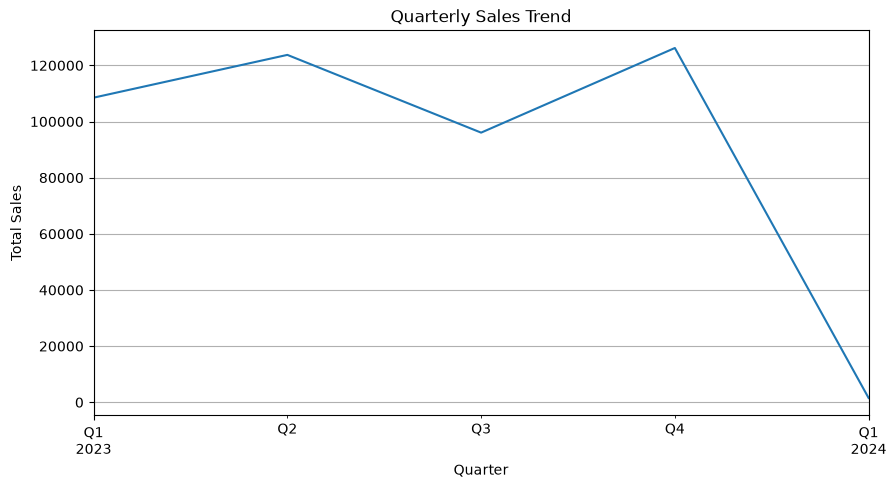

In [31]:
quarterly_sales.plot(kind='line', figsize=(10, 5))

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

### Observation: Quarterly Sales Trend

Quarterly sales increased from Q1 to Q2 2023, declined in Q3, and increased again in Q4. Q2 and Q4 recorded the strongest quarterly sales performance. The sharp decline shown in Q1 2024 should be interpreted cautiously because the final period appears to contain incomplete sales data.

In [32]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0, 17, 25, 35, 45, 55, 100],
    labels=['Under 18', '18-25', '26-35', '36-45', '46-55', '56+']
)

In [33]:
df['Age Group'].value_counts()

Age Group
46-55       229
26-35       205
36-45       202
56+         195
18-25       169
Under 18      0
Name: count, dtype: int64

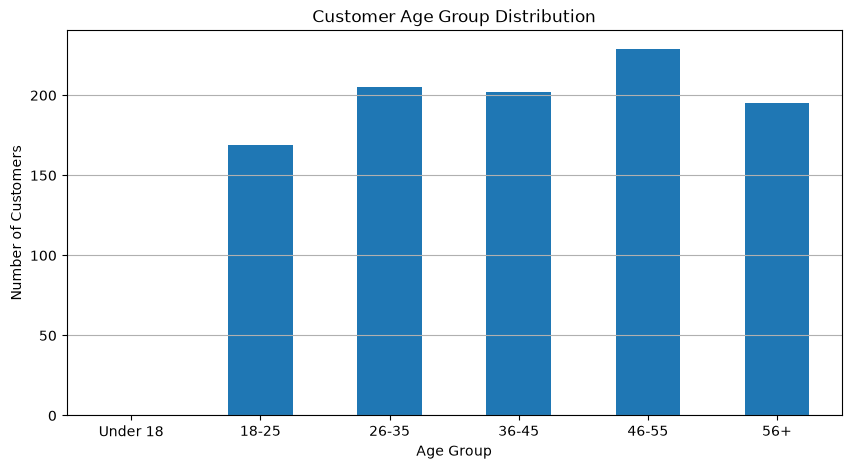

In [34]:
df['Age Group'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

### Observation: Customer Age Group Distribution

Customers aged 46–55 represent the largest age group in the dataset. The 26–35 and 36–45 age groups also have a strong representation, while customers aged 18–25 and 56+ are moderately represented. No customers below 18 were recorded. This suggests that the business primarily serves adult customers, with customers aged 46–55 forming the largest segment.

In [35]:
gender_counts = df['Gender'].value_counts()

In [36]:
gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

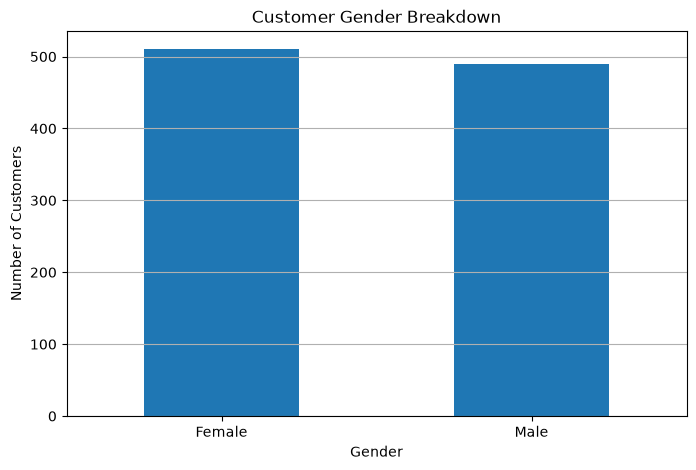

In [37]:
gender_counts.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Customer Gender Breakdown')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

### Observation: Customer Gender Breakdown

The customer base is relatively balanced by gender, although female customers slightly outnumber male customers. This indicates that the business serves both male and female customers without a very large gender imbalance.

In [38]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Age Group'],
      dtype='str')

In [39]:
df['Product Category'].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [40]:
category_quantity = df.groupby('Product Category')['Quantity'].sum()

In [41]:
category_quantity

Product Category
Beauty         771
Clothing       894
Electronics    849
Name: Quantity, dtype: int64

In [42]:
category_quantity = category_quantity.sort_values(ascending=False)

In [43]:
category_quantity

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

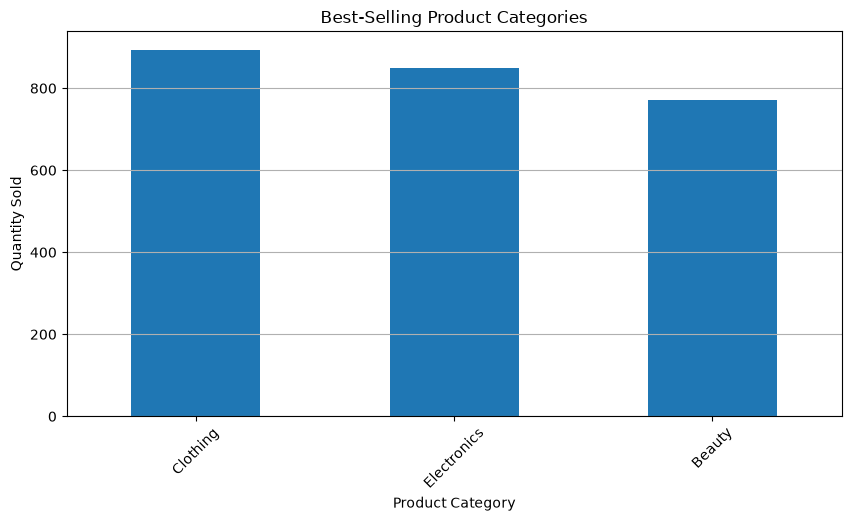

In [44]:
category_quantity.plot(kind='bar', figsize=(10, 5))

plt.title('Best-Selling Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Observation: Best-Selling Product Categories

Clothing recorded the highest quantity sold, followed by Electronics and Beauty. This indicates that Clothing has the strongest sales volume among the three product categories and may be an important category for maintaining inventory and promotional activities.

In [45]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum()

In [46]:
category_revenue

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

In [47]:
category_revenue = category_revenue.sort_values(ascending=False)

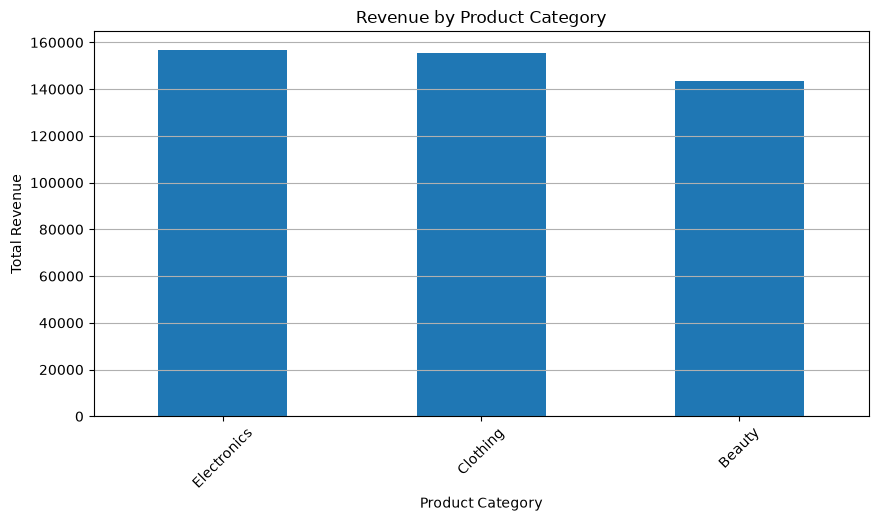

In [48]:
category_revenue.plot(kind='bar', figsize=(10, 5))

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Observation: Revenue by Product Category

Electronics generated the highest revenue, closely followed by Clothing, while Beauty generated the lowest revenue among the three categories. Although Clothing has the highest quantity sold, Electronics generates slightly more revenue, suggesting that Electronics products may have a higher average selling value.

In [49]:
correlation_matrix = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()

In [50]:
correlation_matrix

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


In [51]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [52]:
import seaborn as sns

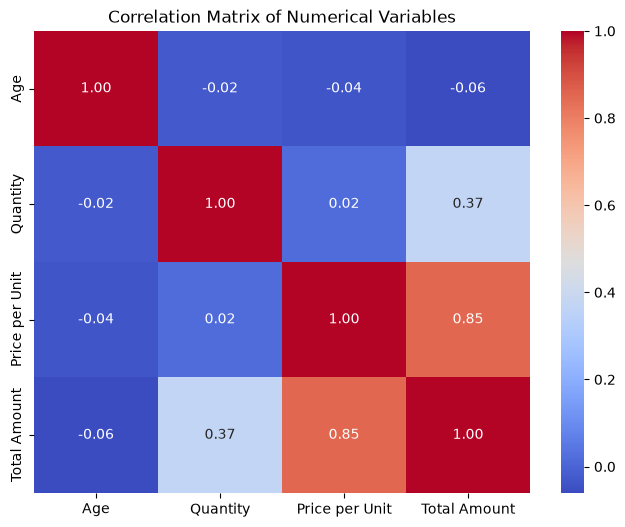

In [53]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### Observation: Correlation Analysis

The correlation matrix shows a strong positive relationship between Price per Unit and Total Amount (0.85). Quantity also has a moderate positive relationship with Total Amount (0.37). Age has very weak relationships with both Quantity and Total Amount, indicating that customer age does not appear to strongly influence transaction value in this dataset.

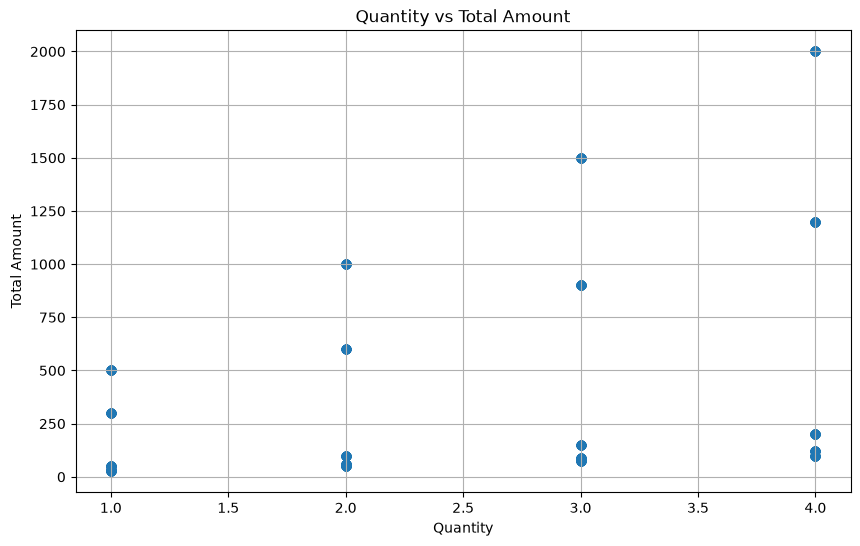

In [54]:
plt.figure(figsize=(10, 6))

plt.scatter(df['Quantity'], df['Total Amount'])

plt.title('Quantity vs Total Amount')
plt.xlabel('Quantity')
plt.ylabel('Total Amount')
plt.grid(True)
plt.show()

### Observation: Quantity vs Total Amount

The scatter plot shows a positive relationship between quantity purchased and total transaction amount. However, transactions with the same quantity can have very different total amounts, suggesting that Price per Unit also plays an important role in determining transaction value. This supports the strong correlation observed between Price per Unit and Total Amount.

# Conclusion

The analysis of the retail sales dataset revealed several important patterns in sales performance, customer demographics, and product categories. Sales fluctuated over time, with stronger performance recorded in Q2 and Q4 of 2023. Clothing had the highest quantity sold, while Electronics generated the highest revenue. The customer base was relatively balanced by gender, with female customers slightly outnumbering male customers. Customers aged 46–55 formed the largest age group.

The correlation analysis showed a strong positive relationship between Price per Unit and Total Amount (0.85), while Quantity had a moderate positive relationship with Total Amount (0.37). Customer age showed very weak relationships with transaction value and quantity.

## Business Recommendations

1. **Prioritize Electronics for revenue growth:** Since Electronics generated the highest revenue, the business should maintain sufficient stock of high-performing electronics products and consider targeted promotions to increase sales further.

2. **Maintain strong inventory levels for Clothing:** Clothing recorded the highest quantity sold. The business should monitor clothing inventory closely, identify the best-performing clothing products, and avoid stock-outs during high-demand periods.

3. **Develop targeted marketing for the 46–55 age group:** Since customers aged 46–55 form the largest customer segment, the business should develop targeted promotions and product recommendations that appeal to this age group.

4. **Use pricing strategically:** The strong correlation between Price per Unit and Total Amount suggests that pricing has a major influence on transaction value. The business should review product pricing, discounts, and premium-product strategies to increase revenue without negatively affecting sales volume.

5. **Investigate low-performing periods:** Sales declined significantly during some months. The business should investigate the causes of these declines and consider seasonal promotions, targeted campaigns, or special offers during weaker sales periods.

6. **Increase Beauty category performance:** Beauty generated lower revenue and had the lowest quantity sold among the three categories. The business could test targeted promotions, product bundles, and customer-specific marketing to improve performance in this category.